# Analyze Xenium data

In [1]:
!pip install spatialdata spatialdata-io spatialdata-plot squidpy scanpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 12.5 MB/s

In [2]:
import warnings
warnings.filterwarnings("ignore")

import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

A reader for Xenium data is available in `spatialdata-io`. We use it to parse and convert to Zarr a [Xenium dataset of Human Lung Cancer](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard).

The cell below downloads the compact 2-FOV version (265 MB) directly and extracts only the files needed for this analysis. The large morphology TIFF images are skipped.

In [3]:
import os, zipfile

ZIP_URL     = "https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip"
ZIP_PATH    = "/content/Xenium_2fov.zip"
xenium_path = "/content/Xenium"
zarr_path   = "/content/Xenium.zarr"

NEEDED = [
    "experiment.xenium",
    "cells.parquet",
    "transcripts.parquet",
    "cell_boundaries.parquet",
    "nucleus_boundaries.parquet",
    "cell_feature_matrix.h5",
    "cells.zarr.zip",
]

if not os.path.exists(ZIP_PATH):
    print("Downloading dataset (265 MB)...")
    !wget -q --show-progress -O {ZIP_PATH} {ZIP_URL}
    print("Download complete!")
else:
    print("Zip already downloaded, skipping.")

os.makedirs(xenium_path, exist_ok=True)
already_extracted = all(os.path.exists(f"{xenium_path}/{f}") for f in NEEDED)

if not already_extracted:
    print("Extracting required files...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        all_names = z.namelist()
        for needed_file in NEEDED:
            matches = [n for n in all_names if n.endswith(needed_file)]
            if matches:
                data = z.read(matches[0])
                with open(f"{xenium_path}/{needed_file}", "wb") as f:
                    f.write(data)
                print(f"  extracted: {needed_file}  ({len(data)/1024**2:.1f} MB)")
            else:
                print(f"  NOT FOUND: {needed_file}")
    print("Extraction complete!")
else:
    print("Files already extracted, skipping.")

/content/Xenium_2fo 100%[===================>] 265.12M  75.4MB/s    in 3.9s    
Download complete!
Extracting required files...
  extracted: experiment.xenium  (0.0 MB)
  extracted: cells.parquet  (0.2 MB)
  extracted: transcripts.parquet  (14.5 MB)
  extracted: cell_boundaries.parquet  (1.0 MB)
  extracted: nucleus_boundaries.parquet  (0.9 MB)
  extracted: cell_feature_matrix.h5  (0.4 MB)
  extracted: cells.zarr.zip  (6.6 MB)
Extraction complete!


After downloading and extracting the dataset into a directory named Xenium, we specify the path to the dataset and where we want to store our Zarr files.

In [4]:
print("xenium_path:", xenium_path)
print("zarr_path  :", zarr_path)

xenium_path: /content/Xenium
zarr_path  : /content/Xenium.zarr


load the data into a spatialdata object using the xenium reader.

In [5]:
sdata = xenium(
    xenium_path,
    morphology_mip=False,
    morphology_focus=False,
    cells_labels=False,
    nucleus_labels=False,
)

WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


Convert to Zarr.

In [6]:
sdata.write(zarr_path, overwrite=True)

From now on we only read directly from the zarr store.

In [7]:
sdata = sd.read_zarr(zarr_path)
sdata

SpatialData object, with associated Zarr store: /content/Xenium.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (11898, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (11898, 289)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

For the analysis we use the `anndata.AnnData` object, which contains the count matrix, cell and gene annotations. It is stored in the `spatialdata.tables` layer.

In [8]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [9]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count
0,aaafiiei-1,67,0,0,0,0,67,139.126411,29.125782,cell_circles,5.0,1.0
1,aaanbaof-1,69,0,0,0,0,69,154.434381,31.519064,cell_circles,5.0,1.0
2,aabdiein-1,63,0,0,0,0,63,148.247974,25.693907,cell_circles,5.0,1.0
3,aabfemmf-1,78,0,0,0,0,78,120.251098,33.551095,cell_circles,5.0,1.0
4,aacflbgf-1,19,0,0,0,0,19,31.067501,8.128125,cell_circles,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11893,oigahkgf-1,52,0,0,0,0,52,32.918907,21.268595,cell_circles,5.0,1.0
11894,oigeilci-1,38,0,0,0,0,38,33.415626,21.313751,cell_circles,5.0,1.0
11895,oigjdpec-1,30,0,0,0,0,30,27.319532,16.752969,cell_circles,5.0,1.0
11896,oigkmfoa-1,49,0,0,0,0,49,32.196407,16.030469,cell_circles,5.0,1.0


Squidpy looks for cell coordinates in `.obsm["spatial"]`. By using the Xenium reader from `spatialdata-io` this is already automatically set. For more complex data this needs to be set manually, more details can be found in this [spatialdata tutorial on squidpy integration](https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/squidpy_integration.html).

In [10]:
adata.obsm["spatial"]

array([[ 37.24629974, 667.76745605],
       [ 44.10276031, 701.72283936],
       [ 40.73135757, 684.13360596],
       ...,
       [683.22277832, 359.48660278],
       [685.75463867, 364.47491455],
       [679.56671143, 362.38049316]])

## Calculate quality control metrics

Calculate the quality control metrics on the `anndata.AnnData` using `scanpy.pp.calculate_qc_metrics`.

In [11]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

The percentage of control probes and control codewords can be calculated from `adata.obs`

In [12]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.002462100746426876
Negative decoding count % : 0.005334551617258232


Next we plot the distribution of total transcripts per cell, unique transcripts per cell, area of segmented cells and the ratio of nuclei area to their cells

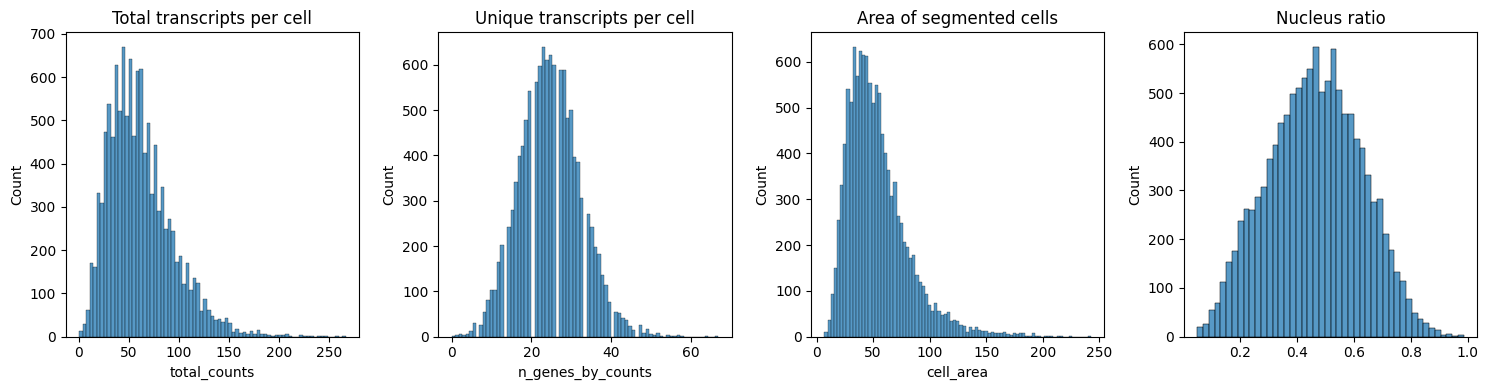

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)

axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)
plt.tight_layout()
plt.show()

Filter the cells based on the minimum number of counts required using `scanpy.pp.filter_cells`. Filter the genes based on the minimum number of cells required with `scanpy.pp.filter_genes`. The parameters for the both were specified based on the plots above. They were set to filter out the cells and genes with minimum counts and minimum cells respectively.

Other filter criteria might be cell area, DAPI signal or a minimum of unique transcripts.

In [14]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

Normalize counts per cell using `scanpy.pp.normalize_total`.

Logarithmize, do principal component analysis, compute a neighborhood graph of the observations using `scanpy.pp.log1p`, `scanpy.pp.pca` and `scanpy.pp.neighbors` respectively.

Use `scanpy.tl.umap` to embed the neighborhood graph of the data and cluster the cells into subgroups employing `scanpy.tl.leiden`.

In [16]:
!pip install leidenalg -q
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 34.0 MB/s eta 0:00:00


## Visualize annotation on UMAP and spatial coordinates

Subplot with scatter plot in UMAP (Uniform Manifold Approximation and Projection) basis. The embedded points were colored, respectively, according to the total counts, number of genes by counts, and leiden clusters in each of the subplots. This gives us some idea of what the data looks like.

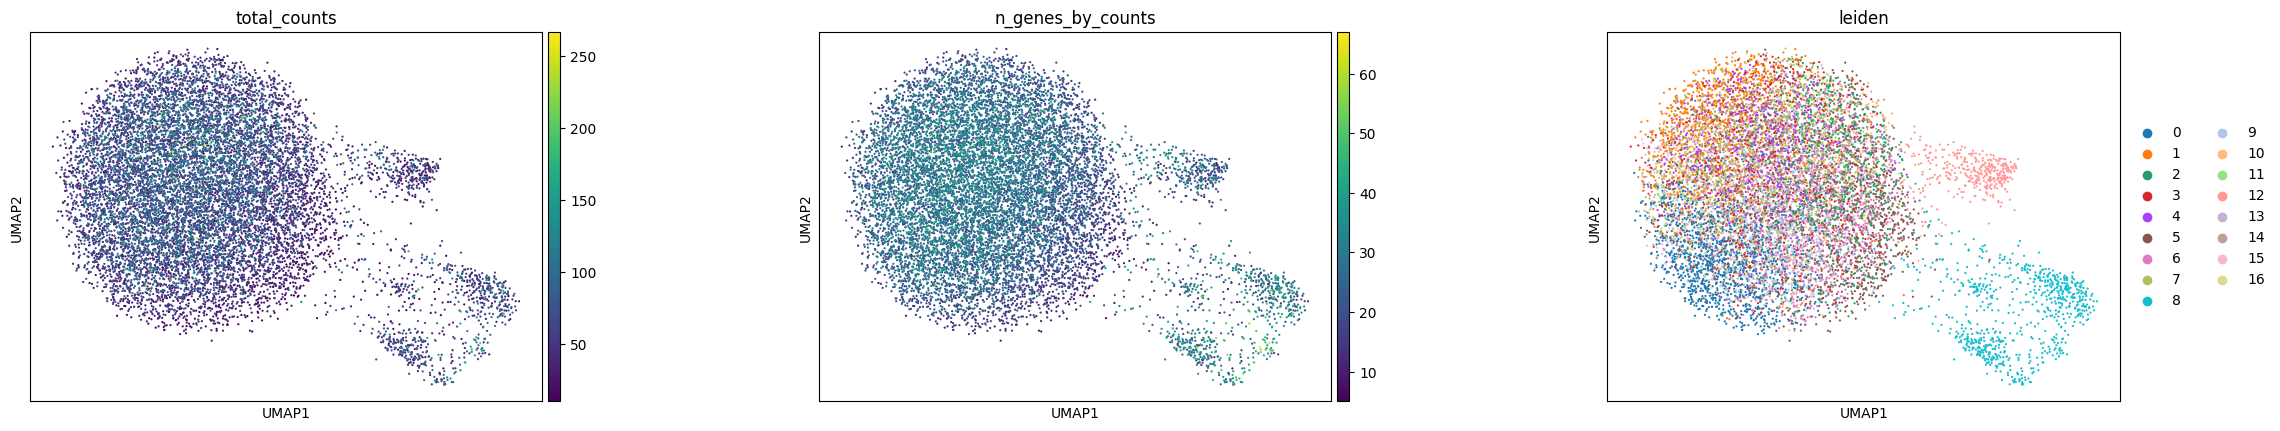

In [17]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

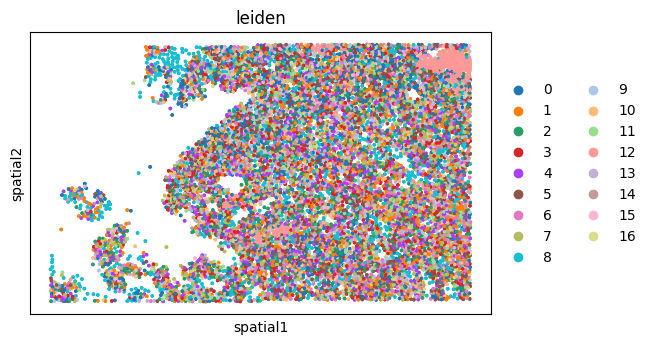

In [18]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

## Computation of spatial statistics

This example shows how to compute centrality scores, given a spatial graph and cell type annotation.

The scores calculated are closeness centrality, degree centrality and clustering coefficient with the following properties:

- closeness centrality - measure of how close the group is to other nodes.
- clustering coefficient - measure of the degree to which nodes cluster together.
- degree centrality - fraction of non-group members connected to group members.

All scores are descriptive statistics of the spatial graph.

This dataset contains Leiden cluster groups' annotations in `adata.obs`, which are used for calculation of centrality scores.

### Building a spatial neighborhood graph

First, we need to compute a connectivity matrix from spatial coordinates to calculate the centrality scores. We can use `squidpy.gr.spatial_neighbors` for this purpose. We use the `coord_type="generic"` based on the data and the neighbors are classified with Delaunay triangulation by specifying `delaunay=True`.

In [19]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


### Compute centrality scores

Centrality scores are calculated with `squidpy.gr.centrality_scores`, with the Leiden groups as clusters.

In [20]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

The results were visualized by plotting the average centrality, closeness centrality, and degree centrality using `squidpy.pl.centrality_scores`.

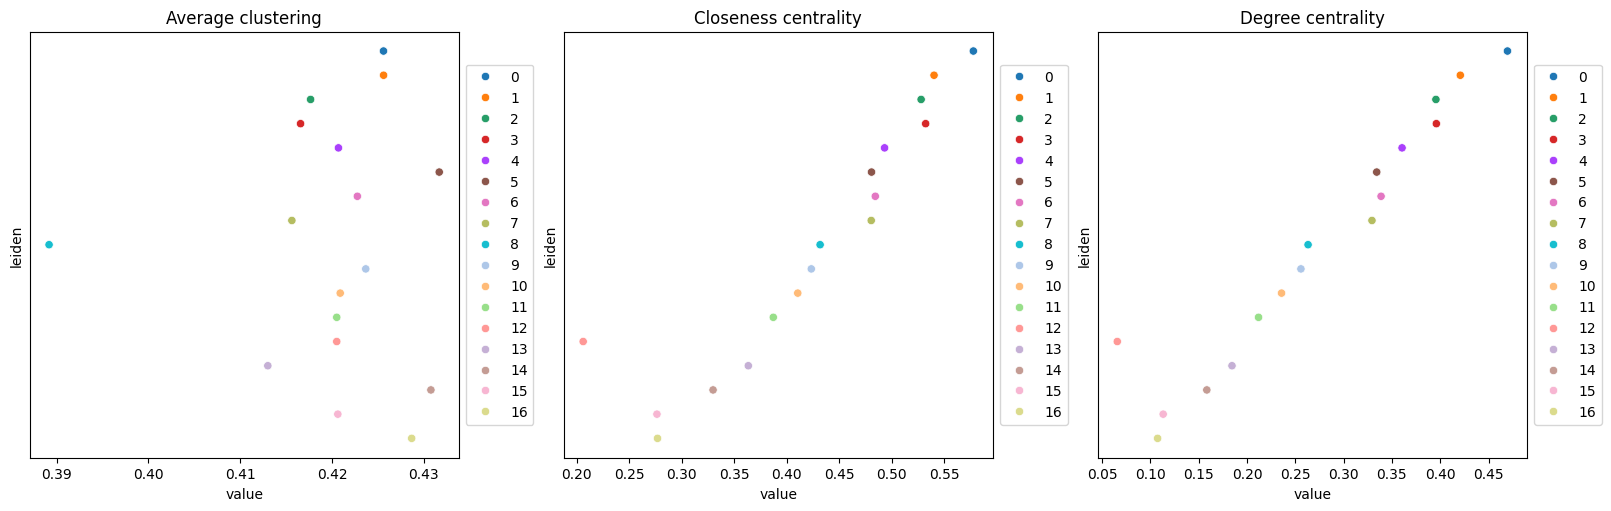

In [21]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

### Compute co-occurrence probability

This example shows how to compute the co-occurrence probability.

The co-occurrence score is defined as:

$\frac{p(exp|cond)}{p(exp)}$

where $p(exp|cond)$ is the conditional probability of observing a cluster $exp$ conditioned on the presence of a cluster $cond$, whereas $p(exp)$ is the probability of observing $exp$ in the radius size of interest. The score is computed across increasing radii size around each cell in the tissue.

We can compute the co-occurrence score with `squidpy.gr.co_occurrence`. Results of co-occurrence probability ratio can be visualized with `squidpy.pl.co_occurrence`. The '12' in the $\frac{p(exp|cond)}{p(exp)}$ represents a Leiden clustered group.

We can further visualize tissue organization in spatial coordinates with `squidpy.pl.spatial_scatter`, with an overlay of the expressed genes which were colored in consonance with the Leiden clusters.

First we create a new table, which is a subset of the original Anndata object, and store it in tables.

In [22]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

You can also work with `sdata.tables["subsample"]` directly, but to keep verbosity low, we just use the `anndata.Anndata` object as before.

In [23]:
adata_subsample = sdata.tables["subsample"]

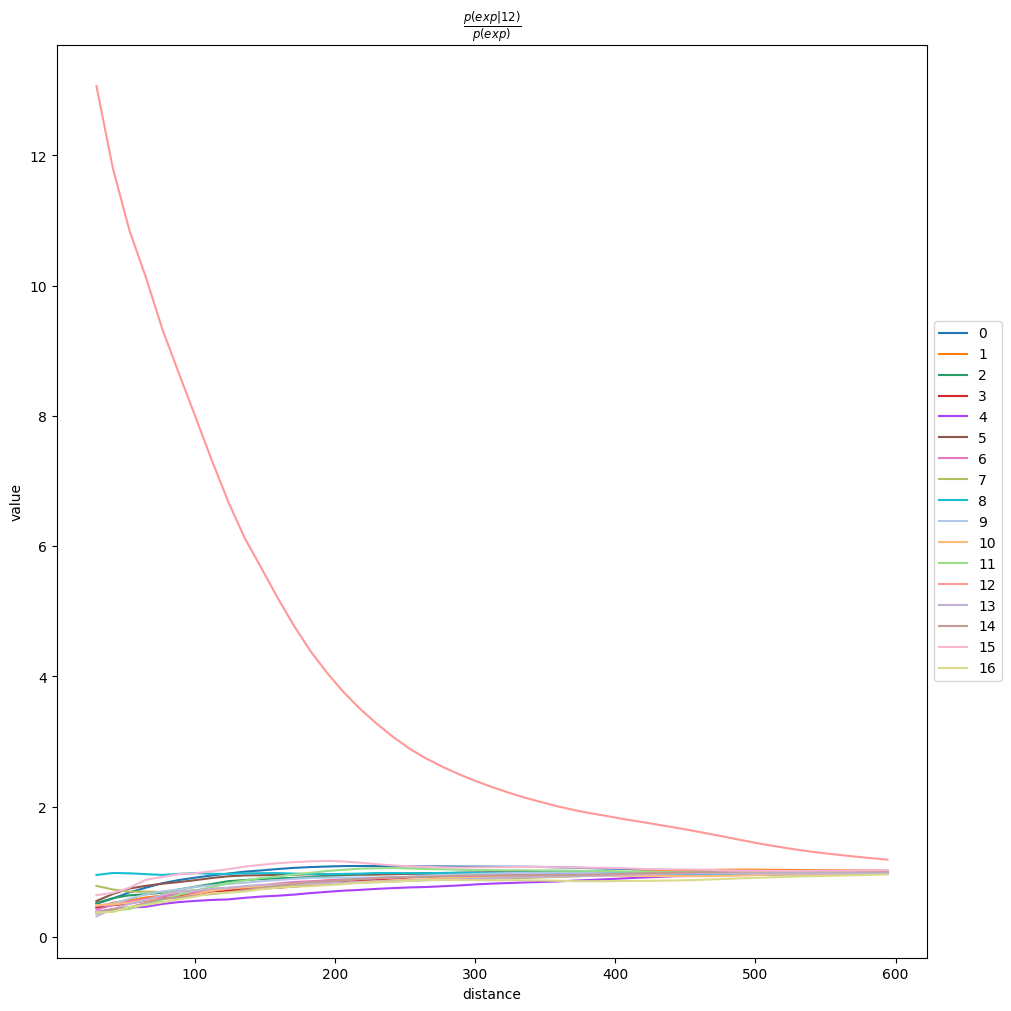

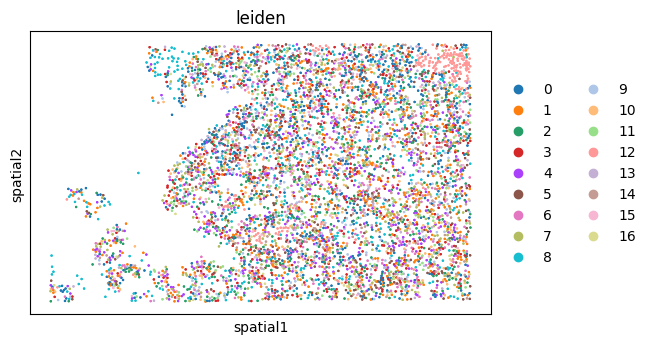

In [24]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

### Neighbors enrichment analysis

This example shows how to run the neighbors enrichment analysis routine.

It calculates an enrichment score based on proximity on the connectivity graph of cell clusters. The number of observed events is compared against permutations and a z-score is computed.

This dataset contains cell type annotations in `adata.obs` which are used for calculation of the neighborhood enrichment. We calculate the neighborhood enrichment score with `squidpy.gr.nhood_enrichment`.

In [25]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

  0%|          | 0/1000 [00:00<?, ?/s]

And visualize the results with `squidpy.pl.nhood_enrichment`.

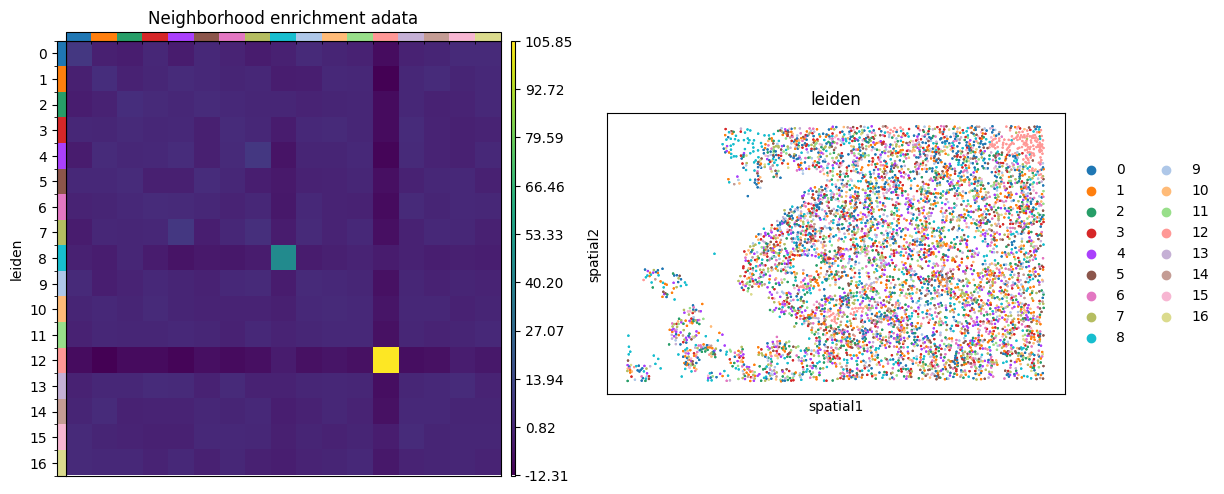

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

### Compute Moran's I score

This example shows how to compute the Moran's I global spatial auto-correlation statistics.

The Moran's I global spatial auto-correlation statistics evaluates whether features (i.e. genes) shows a pattern that is clustered, dispersed or random in the tissue are under consideration.

We can compute the Moran's I score with `squidpy.gr.spatial_autocorr` and mode = 'moran'. We first need to compute a spatial graph with `squidpy.gr.spatial_neighbors`. We will also subset the number of genes to evaluate.

In [27]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
GJA5,0.342052,0.0,0.000057,0.0,0.009901,0.000067,0.0,0.0,0.023913
IGFBP3,0.311425,0.0,0.000057,0.0,0.009901,0.000064,0.0,0.0,0.023913
CXCL13,0.255999,0.0,0.000057,0.0,0.009901,0.000057,0.0,0.0,0.023913
ANPEP,0.217560,0.0,0.000057,0.0,0.009901,0.000040,0.0,0.0,0.023913
PLA2G7,0.204977,0.0,0.000057,0.0,0.009901,0.000060,0.0,0.0,0.023913
GPX2,0.199830,0.0,0.000057,0.0,0.009901,0.000050,0.0,0.0,0.023913
MYH11,0.192787,0.0,0.000057,0.0,0.009901,0.000054,0.0,0.0,0.023913
LTBP2,0.187088,0.0,0.000057,0.0,0.009901,0.000047,0.0,0.0,0.023913
DIRAS3,0.163331,0.0,0.000057,0.0,0.009901,0.000039,0.0,0.0,0.023913
AGR3,0.158846,0.0,0.000057,0.0,0.009901,0.000048,0.0,0.0,0.023913


We can visualize some of those genes with `squidpy.pl.spatial_scatter`. We could also pass `mode = 'geary'` to compute a closely related auto-correlation statistic, Geary's C. See `squidpy.gr.spatial_autocorr` for more information.

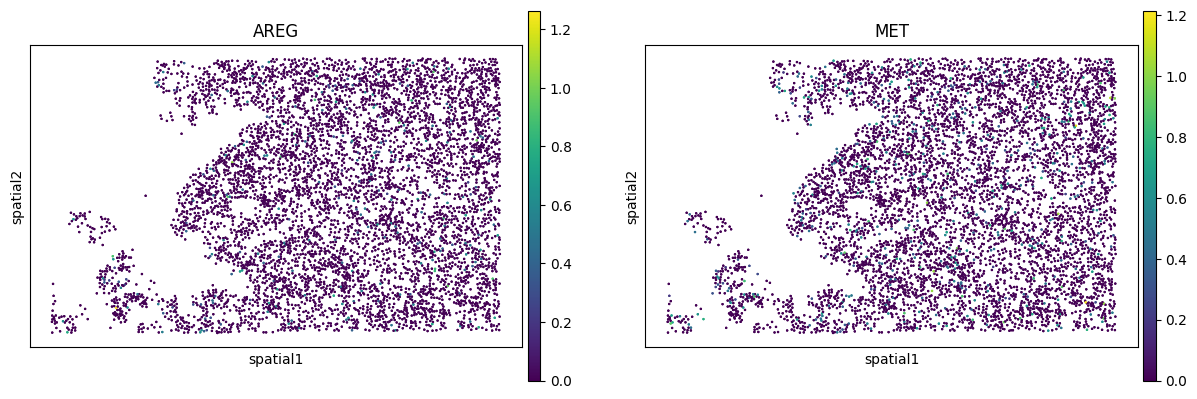

In [28]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "AREG",
        "MET",
    ],
    shape=None,
    size=2,
    img=False,
)

For plotting we can also use `spatialdata-plot`, a package for static plotting of `spatialdata` objects.

Note: this cell requires the morphology_focus image which is only available if the full dataset was downloaded. Skip this cell if you used the 2-FOV download without the TIFF images.

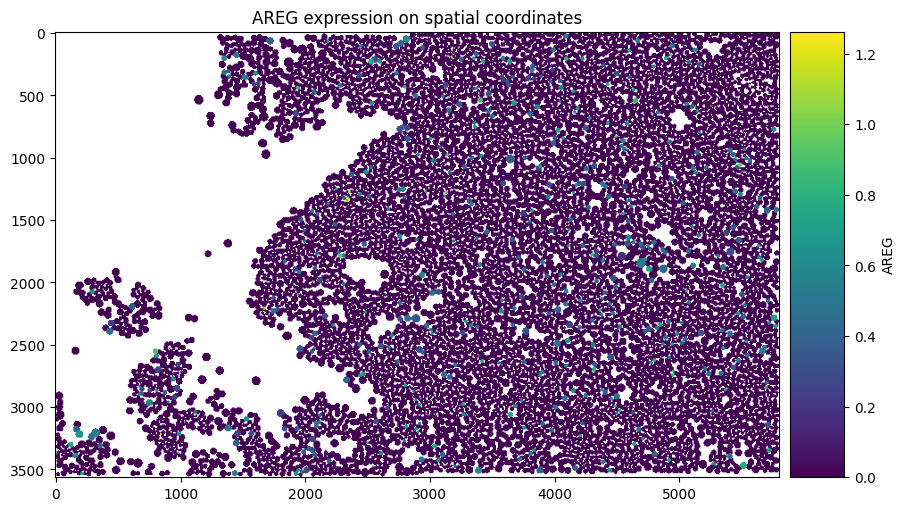

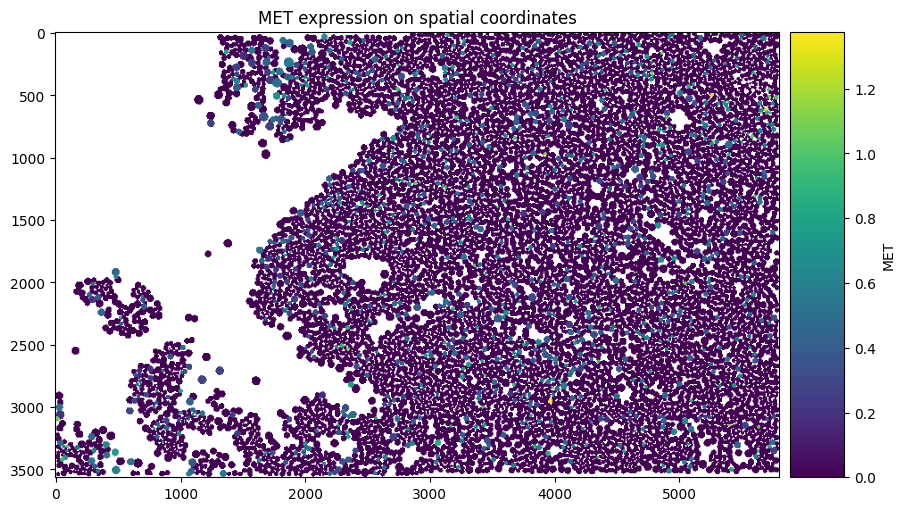

In [30]:
import spatialdata_plot

gene_name = ["AREG", "MET"]
for name in gene_name:
    sdata.pl.render_shapes(
        "cell_circles",
        color=name,
        table_name="table",
        use_raw=False,
    ).pl.show(
        title=f"{name} expression on spatial coordinates",
        coordinate_systems="global",
        figsize=(10, 5),
    )

## Interactive analysis and visualization with `napari-spatialdata`

Additionally, one can use `napari-spatialdata` to visualize Xenium data with an interactive GUI.

In [ ]:
from napari_spatialdata import Interactive

Interactive(sdata)

Here we visualize AREG expression across all cells: